In [9]:
# imports
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from dotenv import load_dotenv
from sqlalchemy.orm.base import state_str

load_dotenv()
import os
os.environ["LANGCHAIN_PROJECT"] = "SHORT_TERM_MEMORY"

In [4]:
# LLM
llm = HuggingFacePipeline.from_model_id(
        model_id="Qwen/Qwen2.5-3B-Instruct",
        task="text-generation",
        pipeline_kwargs={
            "temperature": 0.2,
            "return_full_text":False,
        },
    )
chat_model = ChatHuggingFace(llm=llm)

/Users/jayeshp/PycharmProjects/Langgraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 434/434 [00:00<00:00, 6342.52it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [10]:
# db
conn = sqlite3.connect(database="test.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [11]:
# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# chat node
def chat_node(state: ChatState):
    response = chat_model.invoke(state["messages"])
    return {"messages": [response]}


# graph
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(checkpointer=checkpointer)

In [14]:
# invoke
initial_state = {"messages": [HumanMessage(content="what is 2 + 6 *8")]}
config = {"configurable": {"thread_id": "1"}}
response_state = chatbot.invoke(input=initial_state, config=config)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [15]:
response_state

{'messages': [HumanMessage(content='Hi I am Jayesh', additional_kwargs={}, response_metadata={}, id='10994f45-1b7c-4bef-a80f-75a9f8b48fa9'),
  AIMessage(content="Hello Jayesh! It's nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={}, id='lc_run--01a06338-4765-78e1-bb38-81b6e44e1050-0', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what is 2 + 6 *8', additional_kwargs={}, response_metadata={}, id='6b087a6a-5ed0-4304-9eaa-e8ab8903f432'),
  AIMessage(content='To solve the expression \\(2 + 6 \\times 8\\), you need to follow the order of operations, often remembered by the acronym PEMDAS (Parentheses, Exponents, Multiplication and Division (from left to right), Addition and Subtraction (from left to right)).\n\nAccording to this rule, you first perform the multiplication before the addition:\n\n\\[ 6 \\times 8 = 48 \\]\n\nThen you add 2 to the result:\n\n\\[ 2 + 48 = 

 # trimming

In [16]:
# imports
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [26]:
MAX_TOKENS = 80

In [27]:
# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# chat node
def chat_node(state: ChatState):
    # trimming
    messages = trim_messages(state["messages"], strategy="last", token_counter=count_tokens_approximately, max_tokens=MAX_TOKENS)

    response = chat_model.invoke(messages)
    return {"messages": [response]}


# graph
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(checkpointer=checkpointer)

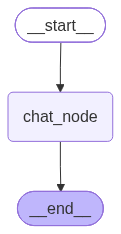

In [28]:
chatbot

In [29]:
# invoke
initial_state = {"messages": [HumanMessage(content="write essay on home")]}
config = {"configurable": {"thread_id": "3"}}
chatbot.invoke(input=initial_state, config=config)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'messages': [HumanMessage(content='write essay on home', additional_kwargs={}, response_metadata={}, id='20d73e28-814d-4ffc-9e60-e6dcfdfe0e5b'),
  AIMessage(content='Certainly! Here\'s an essay on the concept of "Home":\n\n---\n\n**The Essence of Home**\n\nIn the vast tapestry of human experience, few concepts hold as profound and universal significance as "home." It is more thanxA place; it is a sanctuary, a haven, a reflection of one’s identity and emotional well-being. The idea of home is deeply rooted in our cultural, social, and personal experiences, serving as a foundation for our lives and a source of comfort and security.\n\n### Origins and Significance\n\nThe concept of home has evolved over millennia, shaped by various cultures and historical contexts. For many, home is a physical structure—a house or a building where they live. However, its essence transcends mere architecture. Home is a place where memories are made, stories are told, and dreams are nurtured. It is a space

In [30]:
# invoke
initial_state = {"messages": [HumanMessage(content="write essay on dog")]}
config = {"configurable": {"thread_id": "3"}}
chatbot.invoke(input=initial_state, config=config)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'messages': [HumanMessage(content='write essay on home', additional_kwargs={}, response_metadata={}, id='20d73e28-814d-4ffc-9e60-e6dcfdfe0e5b'),
  AIMessage(content='Certainly! Here\'s an essay on the concept of "Home":\n\n---\n\n**The Essence of Home**\n\nIn the vast tapestry of human experience, few concepts hold as profound and universal significance as "home." It is more thanxA place; it is a sanctuary, a haven, a reflection of one’s identity and emotional well-being. The idea of home is deeply rooted in our cultural, social, and personal experiences, serving as a foundation for our lives and a source of comfort and security.\n\n### Origins and Significance\n\nThe concept of home has evolved over millennia, shaped by various cultures and historical contexts. For many, home is a physical structure—a house or a building where they live. However, its essence transcends mere architecture. Home is a place where memories are made, stories are told, and dreams are nurtured. It is a space

In [31]:
# invoke
initial_state = {"messages": [HumanMessage(content="write essay on cat")]}
config = {"configurable": {"thread_id": "3"}}
chatbot.invoke(input=initial_state, config=config)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'messages': [HumanMessage(content='write essay on home', additional_kwargs={}, response_metadata={}, id='20d73e28-814d-4ffc-9e60-e6dcfdfe0e5b'),
  AIMessage(content='Certainly! Here\'s an essay on the concept of "Home":\n\n---\n\n**The Essence of Home**\n\nIn the vast tapestry of human experience, few concepts hold as profound and universal significance as "home." It is more thanxA place; it is a sanctuary, a haven, a reflection of one’s identity and emotional well-being. The idea of home is deeply rooted in our cultural, social, and personal experiences, serving as a foundation for our lives and a source of comfort and security.\n\n### Origins and Significance\n\nThe concept of home has evolved over millennia, shaped by various cultures and historical contexts. For many, home is a physical structure—a house or a building where they live. However, its essence transcends mere architecture. Home is a place where memories are made, stories are told, and dreams are nurtured. It is a space

# summarization

In [32]:
# imports
from langchain_core.messages import RemoveMessage

In [39]:
# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    summary: str

# chat node
def chat_node(state: ChatState):
    msgs = []
    if state["summary"]:
        msgs.append({"role": "system", "content": f'Conversational summary : {state["summary"]}'})

    msgs.extend(state["messages"])

    response = chat_model.invoke(msgs)
    return {"messages": [response]}

# summarize conversation node
def summarize_conversation(state: ChatState):
    summary = state["summary"]
    if summary:
        prompt = (f"Existing summary: {summary}\n\n"
                  f"Extend the summary with new conversation above.")
    else:
        prompt = "Summarize the conversation above."

    messages_to_summarize = state["messages"] + [HumanMessage(content=prompt)]
    response = chat_model.invoke(messages_to_summarize)

    to_delete = state["messages"][:2] # remove index 0, 1
    return {"summary": response.content,
            "messages": [RemoveMessage(id=m.id) for m in to_delete]}

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

# graph
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("summarize_conversation", summarize_conversation)
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_summarize, {True: "summarize_conversation", False: "__end__"})
graph.add_edge("summarize_conversation", END)
chatbot = graph.compile(checkpointer=checkpointer)

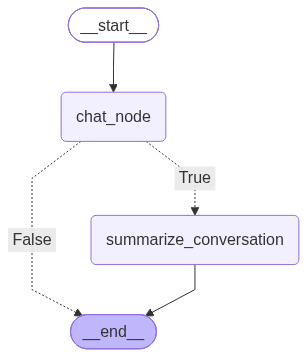

In [40]:
chatbot